# 06 — Director package (October workshop)

Presentation layer over the completed run, per `spec/06_corridors_north_director_package_spec.md`
(v1.1; subordinate to the 05 addendum — methods there, presentation here). Read-only:
`cc.load_results` + `corridors_director` — **zero new solves**. Two acts, one guardrail:
Act 1 the north (room to choose; axis C = the sensitivity on "proposals as given"), Act 2 the
southern edge (options closing). Proposed IPCAs are taken as given, kept visually and tabularly
separable from existing PAs, never readable as a new priority.

Outputs → `output_data/corridors_north/<RUN>/director_package/` (figures/, tables/, deck).
**H8:** the squeezed class ships only once notebook 04 has run `counterfactual_squeeze` (D17);
until then `package()` reports H8 OPEN and withholds it from M1/M3/S4.


In [5]:
# ---- Setup: find the project root, import the shared engines -----------------
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import config
import corridors_core as cc
import corridors_mapstyle as ms          # the style module (spec 06 §3a) -- reload it BEFORE cd,
import corridors_director as cd          # which imports it at module level
for _m in (config, cc, ms, cd):
    importlib.reload(_m)

RUN = "v2_run002"                      # <-- the run to package
R = cc.load_results(config.RESULTS_DIR / "corridors_north" / RUN)
P = cd.package(R, n_examples=7)        # classes (D7/D12/D17), axis-C attribution, jurisdictions, examples
P.examples


v2_run002: results context loaded (58 edges, 41 branches, corridor 33,041 km²)
director package: classes -> both 4 · edge 3 · squeezed 7 · securing 31 | 5 examples | H8 closed


[{'slot': 'N2',
  'act': 1,
  'edge_id': 'E001_028',
  'kind': 'link',
  'title': 'Dene Kʼéh Kusān ↔ Nahanni',
  'side': ['sw', 'ne'],
  'mark': True,
  'options': 'links',
  'option_edges': ['E001_028', 'E023_028'],
  'option_nums': [1, 2],
  'num': '1–2'},
 {'slot': 'N3',
  'act': 1,
  'edge_id': 'E003_026',
  'kind': 'link',
  'title': 'T’akú Tlatsini ↔ Mount Edziza',
  'side': ['sw', 'ne'],
  'mark': True,
  'options': 'links',
  'option_edges': ['E003_026', 'E003_036'],
  'option_nums': [3, 4],
  'num': '3–4'},
 {'slot': 'S1',
  'act': 2,
  'edge_id': 'E019_033',
  'kind': 'link',
  'title': 'Gwillim Lake ↔ Pine Le Moray',
  'side': 'nw',
  'mark': True,
  'option_nums': [5],
  'num': '5'},
 {'slot': 'S2',
  'act': 2,
  'edge_id': 'E005_039',
  'kind': 'link',
  'title': 'Wilps Gwininitxw ↔ Swan Lake Kispiox…',
  'side': 'nw',
  'mark': True,
  'option_nums': [6],
  'num': '6'},
 {'slot': 'S3',
  'act': 2,
  'edge_id': 'E010_033',
  'kind': 'link',
  'title': 'Carp Lake ↔ Pine Le 

## Maps M0–M3 (flat swaths, CVD palette, director legend strings)

M1 the four-class regime map (anchor) · M2 Act 1 securing bands + route options for N2/N3 over
the jurisdiction tint · M3 Act 2 southern zoom, flagged links only (+ the D17 natural-width
outline once H8 is closed) · M4 the N1 with/without Dene Kʼéh Kusān pair.


### M0b — what the land is made of (cartographic contract, spec 06 §3a)

The context figure on the slide template: greyscale cost swatches with water in blue, PAs + IPCAs at 55%, the four corridor classes (only-viable hatched), boundaries; one legend, locator, 100 km bar and north in the furniture column; hand-placed labels from `M0B_SPEC`; PDF + PNG at 300 dpi; the §3a.3 QA checklist printed. Three-second message: *the south is where the cost is*. Previous `map_cost` renders are superseded.


M0b: exported M0b_v2_run002.png, M0b_v2_run002.pdf | font Noto Sans
  [OK] 1 nothing clipped at the frame
  [OK] 2 zero label overlaps / halos / diacritics
  [OK] 3 furniture present, one legend
  [OK] 4 class colours separable (deuteranopia / protanopia)
  [OK] 5 only palette hues
  [OK] 6 layer order
  [OK] 7 export PDF + PNG, fonts embedded
  [OK] 8 three-second message


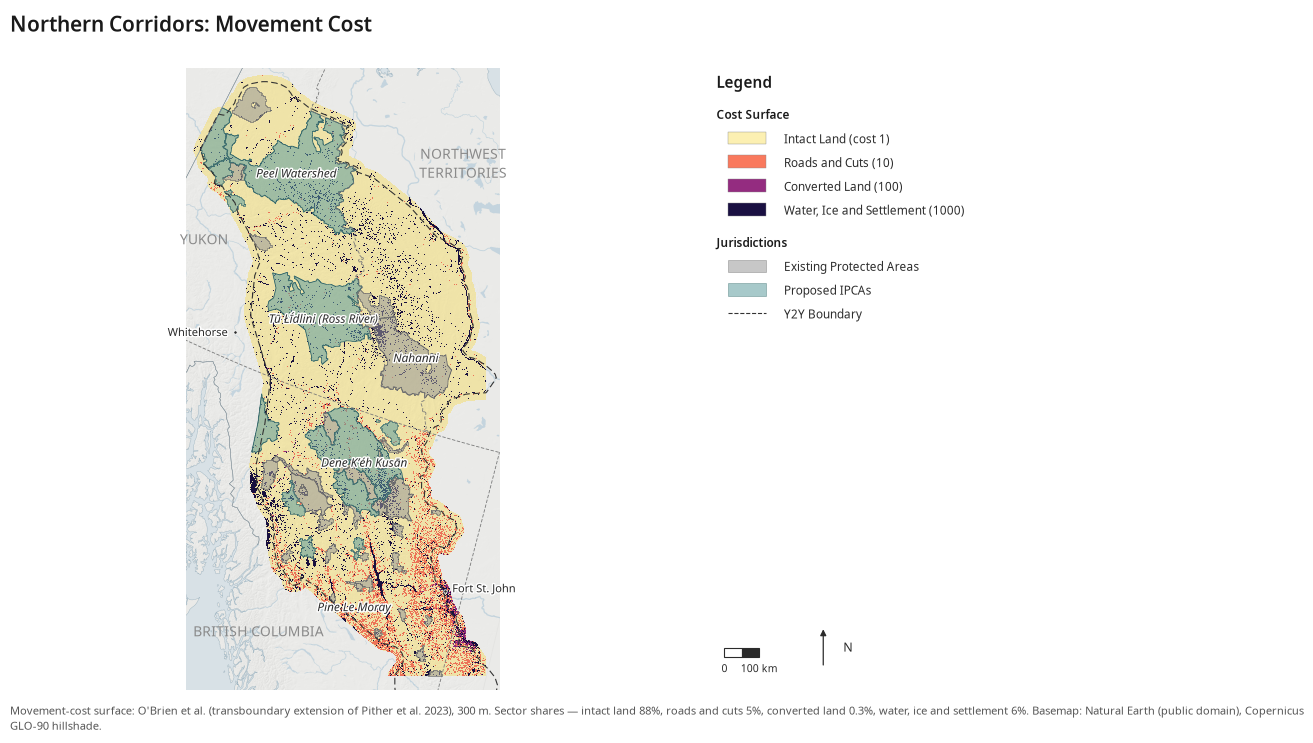

In [6]:
fig = cd.figure_m0b(P)          # spec 06 §3a: slide template, corridors_mapstyle, PDF + PNG, QA checklist


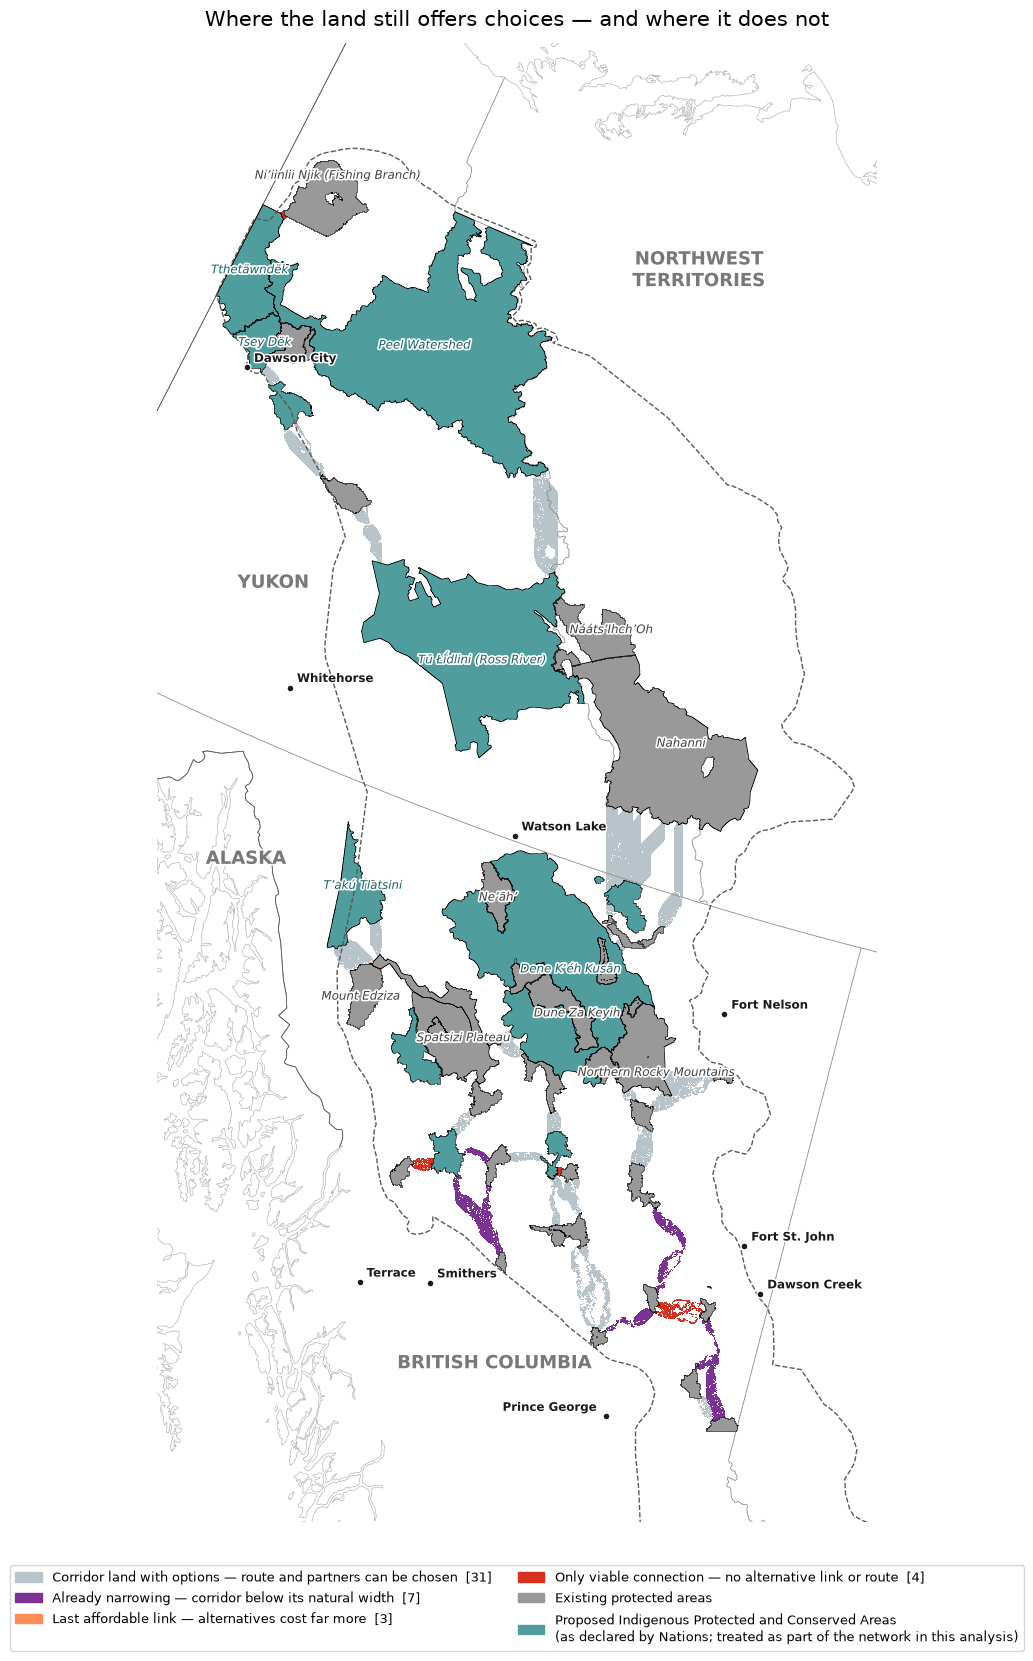

namespace(R=<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>,
          out=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package'),
          fig=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/figures'),
          tab=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/tables'),
          edges=           i   j                                            label_i  \
                edge_id                                                               
                E000_002   0   2                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_006   0   6                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_041   0  41                IPCA · Peel Watershed - SMA/WA (+1)   
                E

In [21]:
cd.map_m1(P)


### M1b — M1 beside the neighbour universe (D21)

Left: M1. Right: every cost-allocation neighbour link as a line between area centres (adjacency-only in blue; backbone backups dashed; minimum-network links heavy) with each area's neighbour count. Lines, never bands — the difference between the panels is the choice space. Needs the D21 products from notebook 04 step 0b (`adjacency_edges.csv`, `adjacency_nodes.csv` in the run dir).


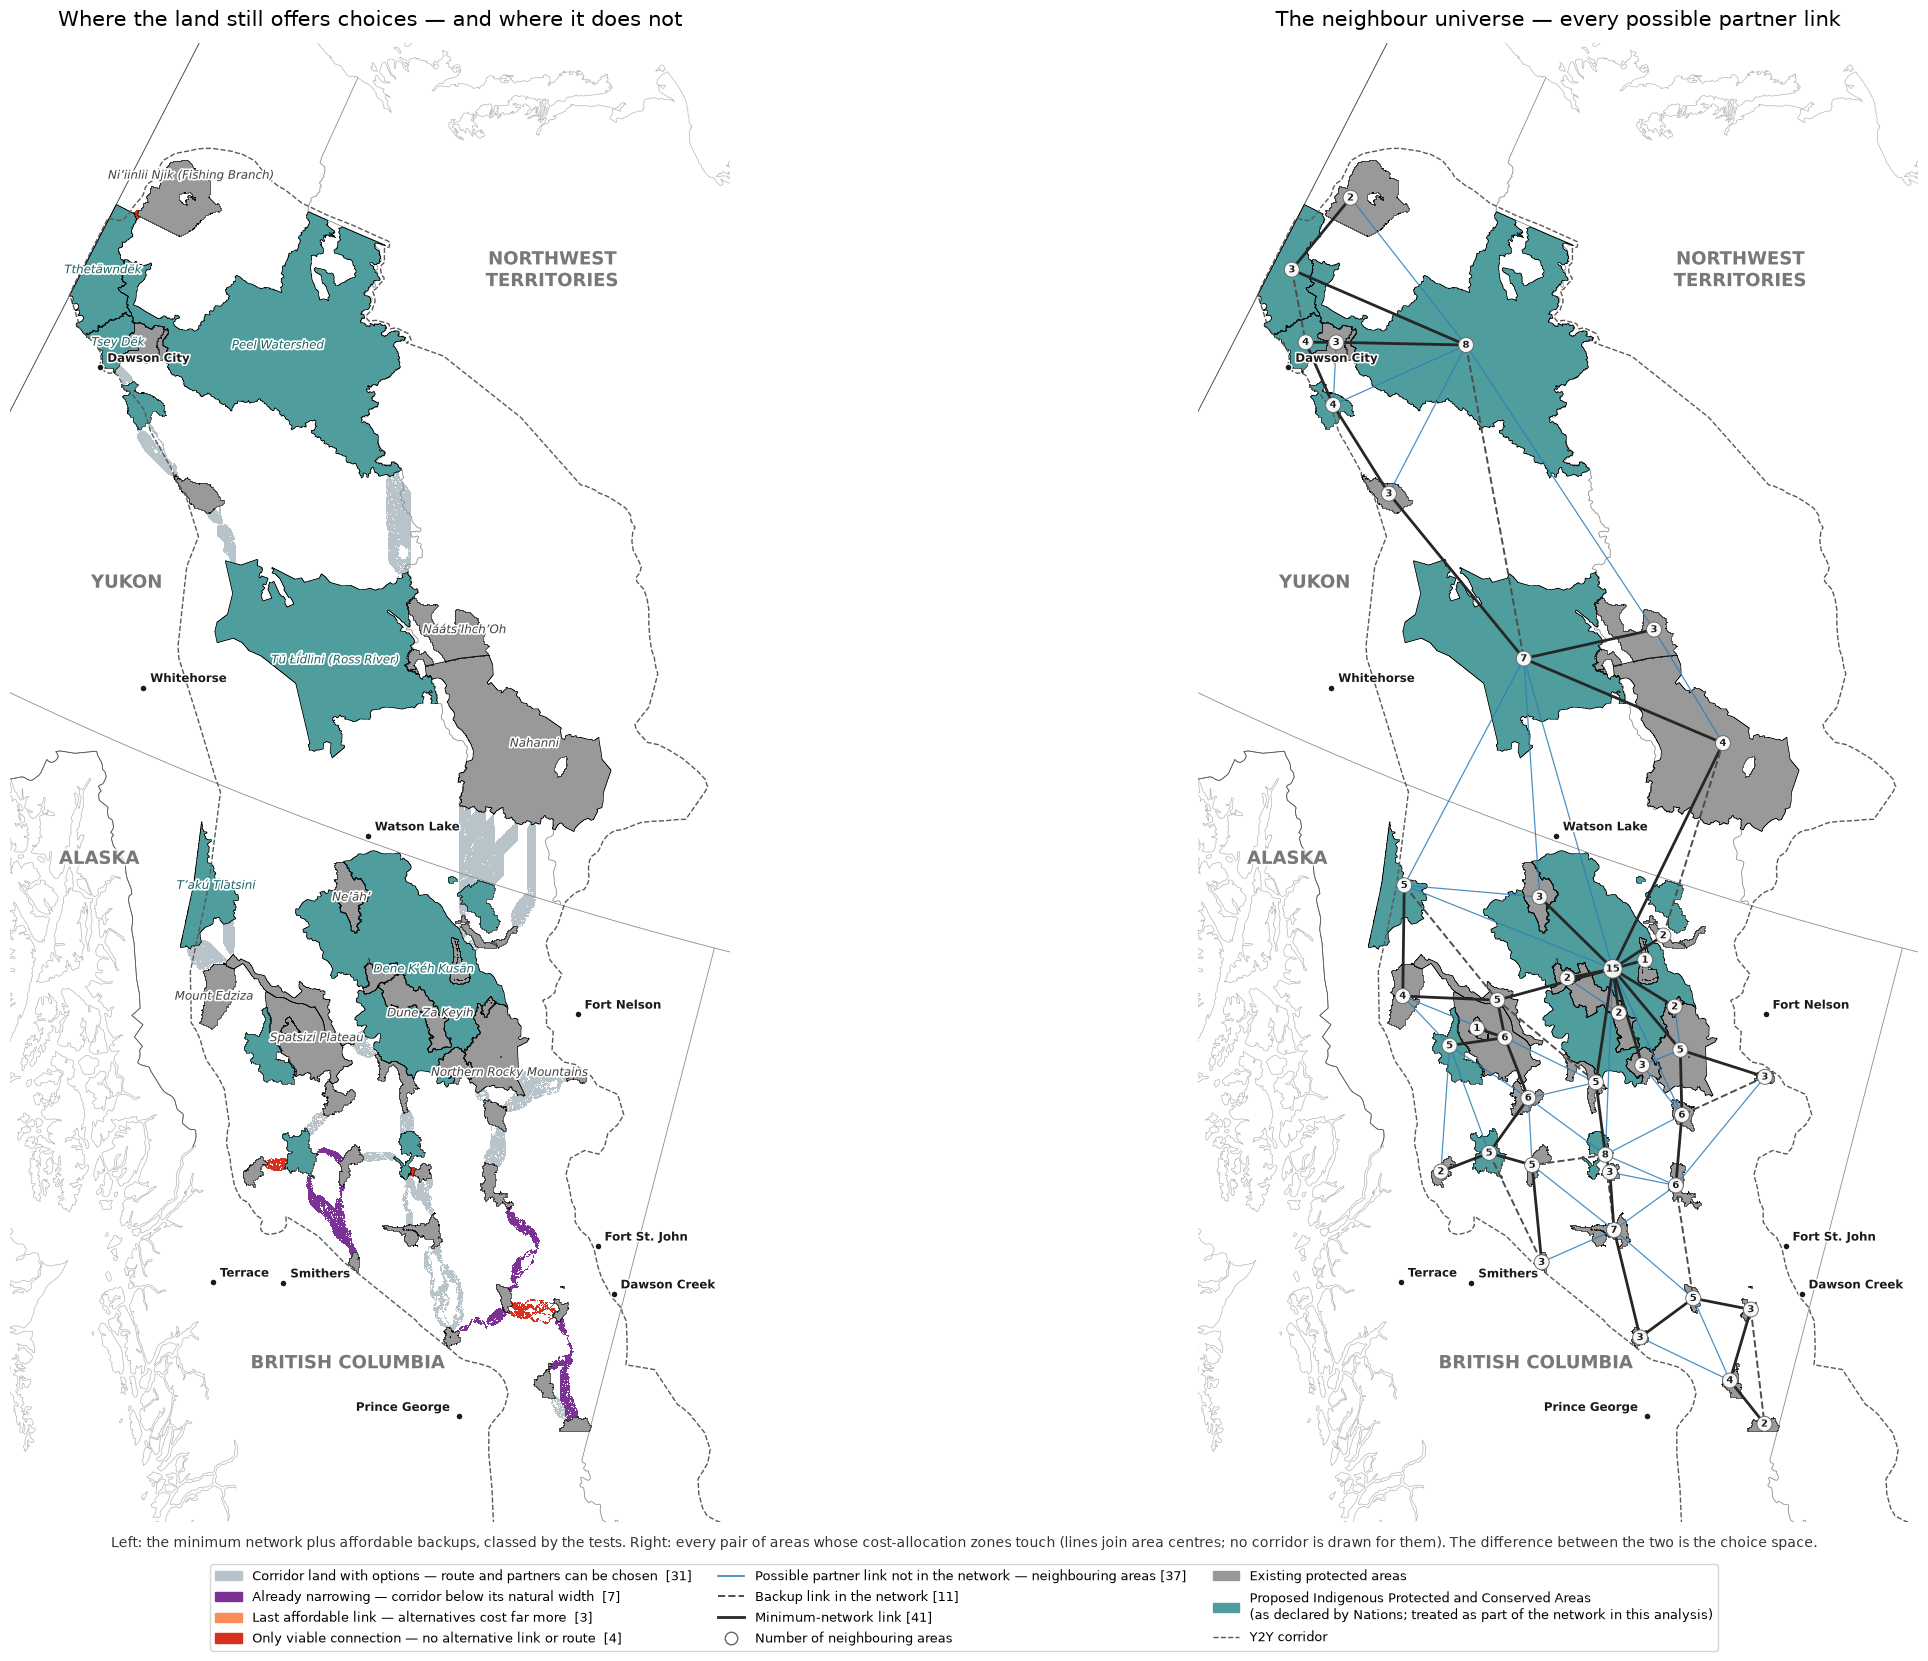

,edge_id,label_i,label_j,i,j,is_adjacent,is_adjacent_euclid,in_backbone,edge_class,in_mst,cost,lcp_len_km_proxy,centreline_km,via_zones,crosses_masks,lm_drop_through_core,lm_beyond_cap
0,E000_002,IPCA · Peel Watershed - SMA/WA (+1),IPCA · Tū Łī́dlini (Ross River),0,2,True,True,True,inter,False,455.639618,131.1,131.4,NaN,NaN,False,False
1,E000_006,IPCA · Peel Watershed - SMA/WA (+1),IPCA · Tthetäwndëk (Tatonduk),0,6,True,True,True,inter,True,1.000000,0.0,0.6,NaN,NaN,False,False
2,NaN,IPCA · Peel Watershed - SMA/WA (+1),IPCA · Tsey Dëk (Fifteenmile),0,7,True,True,False,NaN,False,1.000000,0.0,NaN,NaN,NaN,False,False
3,NaN,IPCA · Peel Watershed - SMA/WA (+1),IPCA · Tintina Trench,0,8,True,True,False,NaN,False,127.622368,37.8,NaN,NaN,NaN,False,False
4,NaN,IPCA · Peel Watershed - SMA/WA (+1),PA · Ddhaw Ghro,0,12,True,True,False,NaN,False,367.421356,101.3,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,L001_002,IPCA · Dene Kʼéh Kusān [part 1],IPCA · Dene Kʼéh Kusān [part 2],1,1,True,True,True,intra_name,True,85.781738,NaN,19.2,PA · Liard River Corridor Park,NaN,False,False
91,L025_027,PA · Liard River Corridor Park [part 1],PA · Liard River Corridor Park [part 3],23,23,True,True,True,intra_name,True,5.242640,NaN,1.5,NaN,NaN,False,False
92,L025_026,PA · Liard River Corridor Park [part 1],PA · Liard River Corridor Park [part 2],23,23,True,True,True,intra_name,True,6.000000,NaN,2.1,NaN,NaN,False,False
93,L032_033,PA · Nahanni National Park Reserve Of Canada [...,PA · Nahanni National Park Reserve Of Canada [...,28,28,True,True,True,intra_name,True,36.485279,NaN,10.5,IPCA · Tū Łī́dlini (Ross River),NaN,False,False


In [22]:
cd.map_adjacency(P)


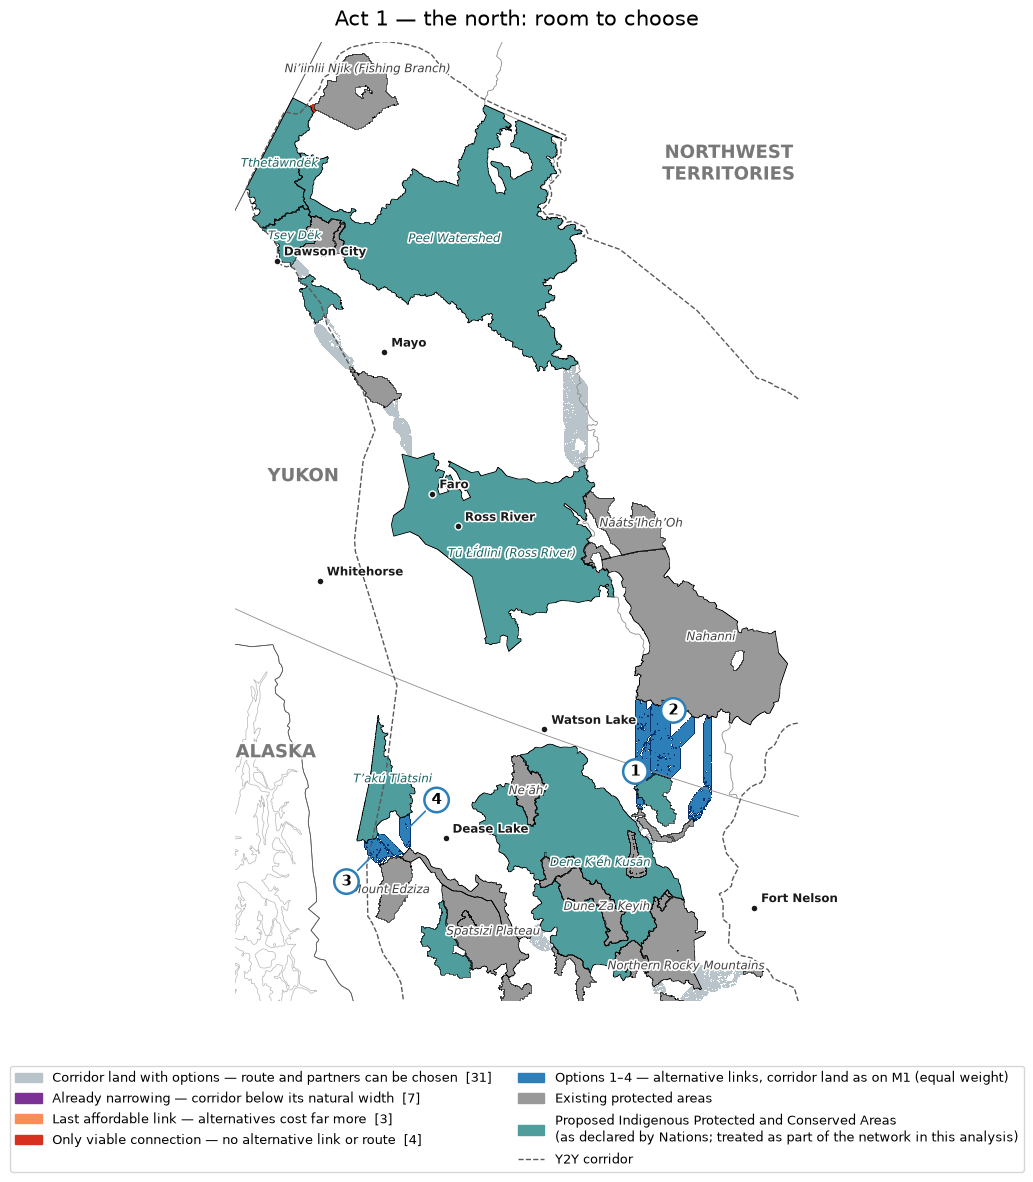

namespace(R=<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>,
          out=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package'),
          fig=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/figures'),
          tab=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/tables'),
          edges=           i   j                                            label_i  \
                edge_id                                                               
                E000_002   0   2                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_006   0   6                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_041   0  41                IPCA · Peel Watershed - SMA/WA (+1)   
                E

In [23]:
cd.map_m2(P)


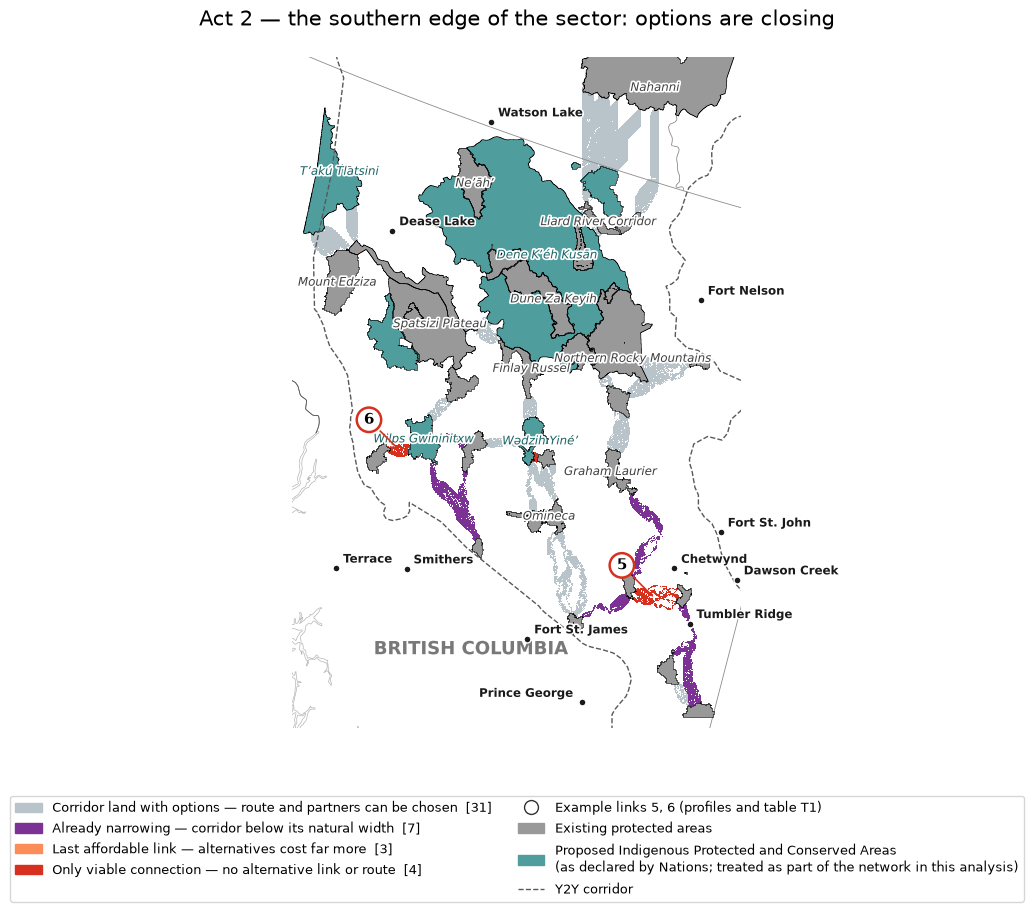

namespace(R=<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>,
          out=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package'),
          fig=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/figures'),
          tab=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_north/v2_run002/director_package/tables'),
          edges=           i   j                                            label_i  \
                edge_id                                                               
                E000_002   0   2                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_006   0   6                IPCA · Peel Watershed - SMA/WA (+1)   
                E000_041   0  41                IPCA · Peel Watershed - SMA/WA (+1)   
                E

In [24]:
cd.map_m3(P)


## Star plots — what each option delivers

One star per numbered option (1–6) plus the proposed IPCAs and the existing PAs as wholes, on the **Y2Y-wide director construction** (`director_core.block_percentiles` → `plot_star_grid`): each axis = mean percentile of the theme across the option's land, ranked against unprotected land Y2Y-wide (dashed ring 0.5 = typical unprotected land). Decision 2026-09-09: mean percentile, not value-per-area, for both packages. `reference="window"` gives the north-relative reading.


  star plots: 8 profiles -> S1_star_options.png + star_options.csv (reference: all unprotected land in Y2Y)


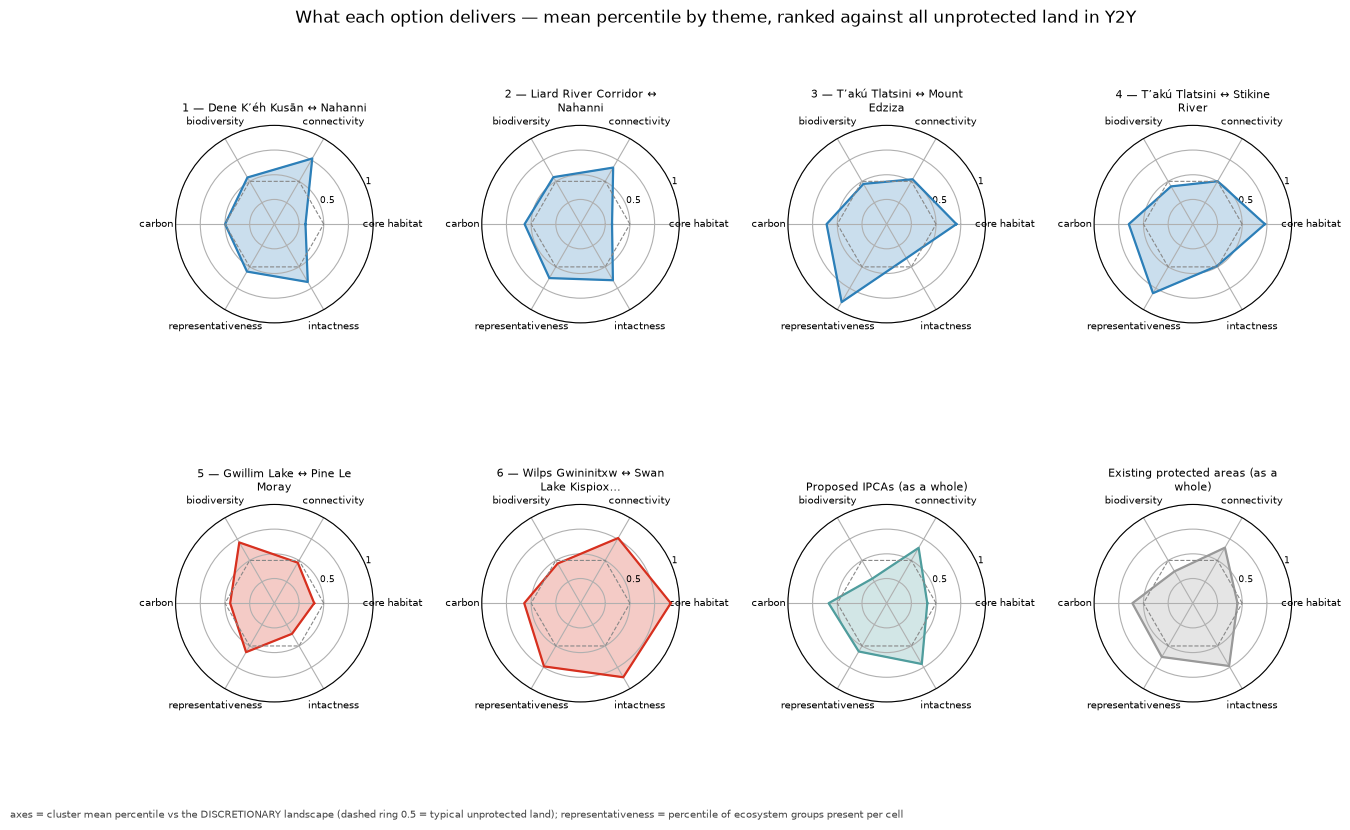

,option,title,km2,core habitat,connectivity,biodiversity,carbon,representativeness,intactness
0,1,Dene Kʼéh Kusān ↔ Nahanni,3703,0.315,0.767,0.545,0.499,0.555,0.677
1,2,Liard River Corridor ↔ Nahanni,4252,0.319,0.661,0.549,0.566,0.631,0.656
2,3,T’akú Tlatsini ↔ Mount Edziza,799,0.706,0.525,0.470,0.609,0.912,0.399
3,4,T’akú Tlatsini ↔ Stikine River,1024,0.730,0.501,0.441,0.648,0.807,0.490
4,5,Gwillim Lake ↔ Pine Le Moray,837,0.403,0.474,0.711,0.447,0.572,0.358
5,6,Wilps Gwininitxw ↔ Swan Lake Kispiox…,366,0.914,0.762,0.464,0.570,0.739,0.866
6,IPCA,Proposed IPCAs (as a whole),158446,0.411,0.647,0.289,0.588,0.565,0.711
7,PA,Existing protected areas (as a whole),84378,0.452,0.650,0.372,0.612,0.628,0.734


In [25]:
stars = cd.star_options(P)          # reference="y2y" (default) | "window"
stars


## Alternatives tables — density and absolute, by theme

Two tables in the y2y-wide consequences format for the numbered options (1–6) plus the proposed IPCAs and the existing PAs as wholes, rows grouped by theme, one column per option (fractional 300 m → 1 km cover weights, M6.5). **Density** = what the land is like: per-cell means, carbon as t C/ha, ecosystem groups per cell — comparable across columns regardless of area. **Absolute** = how much it holds: land, share of Y2Y, carbon totals, groups present, and each value's share of the Y2Y-wide total. Never mixed. Writes `T_options_density` / `T_options_absolute` (.csv + .png).


In [26]:
tab_density = cd.table_options(P, "density")      # what the land is like (per-cell / per-ha)
tab_absolute = cd.table_options(P, "absolute")    # how much it holds (totals, shares of Y2Y)
tab_density


  building 8 continuous + 20 EFG stacks on the 1000 m AUDIT grid…
  alternatives table (density): 8 columns x 10 values -> T_options_density.csv / .png
  building 8 continuous + 20 EFG stacks on the 1000 m AUDIT grid…
  alternatives table (absolute): 8 columns x 11 values -> T_options_absolute.csv / .png


Route options  \
                                                                      1 — Dene Kʼéh Kusān ↔ Nahanni   
theme              value                                                                              
Area               land (km²)                                                                 3,703   
Core habitat       Climate refugia — yr/km (mean; refugial residen...                          0.24   
Connectivity       Connectivity — current density, amperes (mean)                               2.1   
                   Climate corridors — current-flow centrality, am...                           9.6   
Biodiversity       Bird richness — species/cell (mean)                                           67   
                   Mammal richness — species/cell (mean)                                         35   
Carbon             Carbon: mineral soil — t C / ha (mean)                                      31.8   
                   Carbon: biomass — t C / ha (mean)                                             31   
Representativeness Ecosystem groups (EFG) — groups per cell (mean,...                             3   
Intactness         Intactness — intactness 0-1 (mean; 1-gHM)                                   0.99   

                                                                                                          \
                                                                      2 — Liard River Corridor ↔ Nahanni   
theme              value                                                                                   
Area               land (km²)                                                                      4,252   
Core habitat       Climate refugia — yr/km (mean; refugial residen...                               0.24   
Connectivity       Connectivity — current density, amperes (mean)                                    1.7   
                   Climate corridors — current-flow centrality, am...                                9.0   
Biodiversity       Bird richness — species/cell (mean)                                                67   
                   Mammal richness — species/cell (mean)                                              36   
Carbon             Carbon: mineral soil — t C / ha (mean)                                           46.6   
                   Carbon: biomass — t C / ha (mean)                                                  43   
Representativeness Ecosystem groups (EFG) — groups per cell (mean,...                                  3   
Intactness         Intactness — intactness 0-1 (mean; 1-gHM)                                        0.99   

                                                                                                         \
                                                                      3 — T’akú Tlatsini ↔ Mount Edziza   
theme              value                                                                                  
Area               land (km²)                                                                       799   
Core habitat       Climate refugia — yr/km (mean; refugial residen...                              0.76   
Connectivity       Connectivity — current density, amperes (mean)                                   1.2   
                   Climate corridors — current-flow centrality, am...                               8.5   
Biodiversity       Bird richness — species/cell (mean)                                               66   
                   Mammal richness — species/cell (mean)                                             33   
Carbon             Carbon: mineral soil — t C / ha (mean)                                          57.9   
                   Carbon: biomass — t C / ha (mean)                                                 20   
Representativeness Ecosystem groups (EFG) — groups per cell (mean,...                                 4   
Intactness         Intactness — intactness 0-1 (mean; 1-g

## GIS export — layers with the presentation attributes, for ArcGIS Pro / QGIS

`director_package/gis/`: `corridor_pressure.gpkg` (owner-partition polygon per link with the four-class `pressure` field + hex), `areas.gpkg` (PAs / IPCAs by name, `kind` + hex), `options.gpkg` (options 1–6), `style.json` (every colour, opacity and raster path; the cost surface is `resistance.tif` with unique values 1 / 10 / 100 / 1000).


In [ ]:
cd.export_gis(P)
